In [1]:
import ROOT as rt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create an RDataFrame from a ROOT file
pathbase = "TVDumper/DumperTVHits_run_000001_evt_"
kalman_included = True

# Dataflow checking
The following cells are all for checking if the dataflow works as intended (no mismatches)

In [ ]:
f = rt.TFile.Open("monitoring.root")
f.ls()
directory = f.Get("decode_tvclusters/monitor_tree")
# directory.ls()

In [ ]:
tv_clusters_rdf = rt.RDataFrame("decode_tvclusters/monitor_tree_after", "monitoring.root")
tv_clusterIDs_before_rdf = rt.RDataFrame("decode_tvclusters/monitor_tree_before", "monitoring.root")
if (kalman_included):
    kalman_tracks_rdf = rt.RDataFrame("velo_kalman_filter/monitor_tree", "monitoring.root")
fake_clusters_rdf = rt.RDataFrame("FakeClusters", "fake_clusters.root")

In [ ]:
tv_clusters_df = pd.DataFrame(data = tv_clusters_rdf.AsNumpy())
tv_clusterIDs_before_df = pd.DataFrame(data = tv_clusterIDs_before_rdf.AsNumpy())
if (kalman_included):
    kalman_tracks_df = pd.DataFrame(data = kalman_tracks_rdf.AsNumpy())
fake_clusters_df = pd.DataFrame(data = fake_clusters_rdf.AsNumpy())

In [ ]:
combined_df = pd.DataFrame(data = rt.RDataFrame("Hits_detectors", pathbase + "1.root").AsNumpy())
nDFs = 200
for i in range(2, nDFs+1):
    rootDF = rt.RDataFrame("Hits_detectors", pathbase + str(i) + ".root")
    combined_df = pd.concat([combined_df, pd.DataFrame(data = rootDF.AsNumpy())],
                            ignore_index=True)

In [ ]:
pt = combined_df["pt"]
xs = combined_df["Velo_x"]
modules = combined_df["Velo_Module"]
nVeloHits = combined_df["nVeloHits"]
nbHitsVelo = combined_df["nbHits_in_Velo"]

In [ ]:
print(len(pt), len(xs), xs[0], modules[0], nVeloHits[0], nbHitsVelo[0])
print(f"Total number of hits: {(np.sum(nVeloHits))}")

In [ ]:
positive_pt_indices = np.where(pt > 0)[0]
print(pt, positive_pt_indices)

In [ ]:
plt.hist(combined_df["eta"][positive_pt_indices])
plt.title(r"Distribution of $\eta$ of particles with >1 hit")
plt.xlabel(r"$\eta$")
plt.yscale("log")
plt.show()

In [ ]:
print_xs = []
print_ys = []
print_zs = []
print_ts = []
print_ids = []
print_idxs = []
with open("allen_output.txt", 'r', encoding='utf-8') as file:
    for line in file:
        line = line.strip()  # Remove leading/trailing whitespace
        if not line:
            continue  # Skip empty lines
        
        parts = [part.strip() for part in line.split("=")]
        if parts[0] == "Printing ids: cluster_index, lhcbID, x, y, z, t":
            number_parts = [number_part.strip() for number_part in parts[1].split(",")]
            print_idxs.append(np.uint32(number_parts[0]))
            print_ids.append(np.uint32(number_parts[1]))
            print_xs.append(float(number_parts[2]))
            print_ys.append(float(number_parts[3]))
            print_zs.append(float(number_parts[4]))
            print_ts.append(float(number_parts[5]))

In [ ]:
print_xs = np.array(print_xs)
print_ys = np.array(print_ys)
print_zs = np.array(print_zs)
print_ts = np.array(print_ts)
print_ids = np.array(print_ids)
print_idxs = np.array(print_idxs)

print_zs_unique = np.unique(print_zs)

In [ ]:
np.sum(kalman_tracks_df["eta"] == 0)
relevant_etas = kalman_tracks_df["eta"] < 100
tracks_over_3_hits = kalman_tracks_df["nHits"] > 3
tracks_over_6_hits = kalman_tracks_df["nHits"] > 6
tracks_over_9_hits = kalman_tracks_df["nHits"] > 9

In [ ]:
eta_indices_3 = np.where(relevant_etas * tracks_over_3_hits)[0]
eta_indices_6 = np.where(relevant_etas * tracks_over_6_hits)[0]
eta_indices_9 = np.where(relevant_etas * tracks_over_9_hits)[0]

In [ ]:
plt.hist(kalman_tracks_df["eta"][eta_indices_3], bins=30,
         label=r"$n_{Hit} > 3$", alpha=0.3)
plt.hist(kalman_tracks_df["eta"][eta_indices_6], bins=30,
         label=r"$n_{Hit} > 6$", alpha=0.3)
plt.hist(kalman_tracks_df["eta"][eta_indices_9], bins=30,
         label=r"$n_{Hit} > 9$", alpha=0.3)
plt.title(r"Distribution of $\eta$ of reconstructed tracks with >1 hit")
plt.xlabel(r"$\eta$")
plt.legend()
plt.yscale("log")
plt.show()

In [ ]:
print(fake_clusters_df["id"].size, tv_clusters_df["lhcbID"].size,
      tv_clusterIDs_before_df["lhcbID"].size, print_ids.size)

In [ ]:
print("ID:")
print(np.min(fake_clusters_df["id"]), np.max(fake_clusters_df["id"]))
print(np.min(print_ids), np.max(print_ids))
print(np.min(tv_clusterIDs_before_df["lhcbID"]), np.max(tv_clusterIDs_before_df["lhcbID"]))
print(np.min(tv_clusters_df["lhcbID"]), np.max(tv_clusters_df["lhcbID"]))
print("x:")
print(np.min(fake_clusters_df["x"]), np.max(fake_clusters_df["x"]))
print(np.min(print_xs), np.max(print_xs))
print(np.min(tv_clusters_df["x"]), np.max(tv_clusters_df["x"]))
print("t:")
print(np.min(fake_clusters_df["t"]), np.max(fake_clusters_df["t"]))
print(np.min(print_ts), np.max(print_ts))
print(np.min(tv_clusters_df["t"]), np.max(tv_clusters_df["t"]))

In [ ]:
id_bins = np.linspace(2.95, 3.03, 30) * 1e9

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(fake_clusters_df["id"], bins=id_bins, alpha=0.6, label="Simulated",
         color="red", histtype="step")
vals, bins, _ = axs[0].hist(tv_clusters_df["lhcbID"], bins=id_bins, alpha=0.6,
         label="Decoded, sorted", histtype="step", color="blue")
axs[0].hist(tv_clusterIDs_before_df["lhcbID"], bins=id_bins, alpha=0.6,
         label="Decoded, unsorted", color="green", histtype="step")
axs[0].hist(print_ids, bins=id_bins, alpha=0.6, label="Printed, unsorted",
         color="orange", histtype="step")
axs[0].set_title("Number of LHCbIDs of clusters (U2)")
axs[0].set_xlabel("LHCbID")
axs[0].legend(bbox_to_anchor=(0.12, 0.35))

# Now do x
fc_vals, fc_bins, _ = axs[1].hist(fake_clusters_df["x"], bins=100, alpha=0.6, label="Simulated",
         color="red", histtype="step")
axs[1].hist(tv_clusters_df["x"], bins=100, alpha=0.6,
         label="Decoded, sorted", histtype="step", color="blue")
p_vals, p_bins, _ = axs[1].hist(print_xs, bins=100, alpha=0.6, label="Printed, unsorted",
         color="orange", histtype="step")
axs[1].set_title("x-positions of clusters (U2)")
axs[1].set_xlabel("x")
axs[1].legend(bbox_to_anchor=(0.5, 0.25))
plt.show()

In [ ]:
print(np.sum(p_vals == fc_vals))

# Dataflow matching

In [ ]:
nMatched = nMatchedBefore = nMatchedPrinted = nMatchedPrintedExact = 0
for i, fake_clus_id in enumerate(fake_clusters_df["id"]):
    # check if it was reconstructed
    nMatched += fake_clus_id in tv_clusters_df["lhcbID"]
    nMatchedBefore += fake_clus_id in tv_clusterIDs_before_df["lhcbID"]
    nMatchedPrinted += fake_clus_id in print_ids
    nMatchedPrintedExact += fake_clus_id == print_ids[print_idxs[i]]
    if (i % (fake_clusters_df["id"].size // 20) == 0 and i):
        print(f"Finished {(i * 100 / print_ids.size)}%.")

print(f"Number of matched cluster IDs before and after: {nMatchedBefore}, {nMatched}")

In [ ]:
print(nMatchedPrinted, nMatchedPrintedExact)
print(np.sum(fake_clusters_df["id"] == tv_clusterIDs_before_df["lhcbID"]))
print(np.sum(print_ids == tv_clusterIDs_before_df["lhcbID"]))

In [ ]:
print(np.prod(print_idxs == np.arange(print_idxs.size)))
# print((fake_clusters_df["id"] - print_ids)[100:200])
print((fake_clusters_df["x"] - print_xs)[100:200])
# for i, clusID in enumerate(fake_clusters_df["id"]):
#     if (print_ids[i] != clusID) and i > 2500000:
#         print(f"Index {i}: Not the same values: {print_ids[i]} != {clusID}")

In [ ]:
print(np.sum(np.array(fake_clusters_df["id"]) == print_ids))
print(np.sum(tv_clusterIDs_before_df["lhcbID"] < 0))
print(np.sum(tv_clusters_df["lhcbID"] < 0))
plt.hist(fake_clusters_df["id"] - print_ids, bins=100,
         label="printed", histtype="step")
# plt.hist(fake_clusters_df["id"] - tv_clusterIDs_before_df["lhcbID"], bins=100,
#         label="written to memory", histtype="step")
plt.legend()
plt.title("Histogram of differences between fake cluster and decoded IDs")
plt.show()

In [ ]:
nMatchedTVCluster = 0
for tv_clusID in tv_clusterIDs_before_df["lhcbID"]:
    nMatchedTVCluster += tv_clusID in tv_clusters_df["lhcbID"]

print(f"Number of same clusters in DecodeTVClusters: {nMatchedTVCluster} / {tv_clusters_df["lhcbID"].size}")

# Geometry checking
For anything related to the geometry in case you want to double check any values. There is also a plot of all positions in here.

In [ ]:
geometry_rdfs = [rt.RDataFrame("decode_tvclusters/geo_module", "monitoring.root"),
                rt.RDataFrame("decode_tvclusters/geo_sensCol", "monitoring.root"),
                rt.RDataFrame("decode_tvclusters/geo_ltg", "monitoring.root")]
geometry_dfs = [pd.DataFrame(data = rdf.AsNumpy()) for rdf in geometry_rdfs]

In [ ]:
geo_zs = geometry_dfs[0]["module_z"]
print(np.max(geo_zs))

In [ ]:
xbins = np.linspace(-50, 50, 100)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0,0].hist(fake_clusters_df["x"], bins=xbins, alpha=0.6,
              label="Simulated", color="red", histtype="step")
axs[0,0].hist(tv_clusters_df["x"], bins=xbins, alpha=0.6,
              label="Decoded, after", color="blue", histtype="step")
axs[0,0].hist(print_xs, bins=xbins, alpha=0.6,
              label="Printed, after", color="orange", histtype="step")
axs[0,0].set_title("Histogram of x of clusters (U2)")
axs[0,0].set_xlabel("x")
axs[0,0].legend()

axs[0,1].hist(fake_clusters_df["y"], bins=xbins, alpha=0.6,
              label="Simulated", color="red", histtype="step")
axs[0,1].hist(tv_clusters_df["y"], bins=xbins, alpha=0.6,
              label="Decoded, after", color="blue", histtype="step")
axs[0,1].hist(print_ys, bins=xbins, alpha=0.6,
              label="Printed, after", color="orange", histtype="step")
axs[0,1].set_title("Histogram of y of clusters (U2)")
axs[0,1].set_xlabel("y")
axs[0,1].legend()

plt.subplots_adjust(hspace=0.3)

axs[1,0].hist(fake_clusters_df["z"], bins=1000, alpha=0.6,
              label="Simulated", color="red", histtype="step")
axs[1,0].hist(tv_clusters_df["z"], bins=1000, alpha=0.6,
              label="Decoded, after", color="blue", histtype="step")
axs[1,0].hist(print_zs, bins=1000, alpha=0.6,
              label="Printed, after", color="orange", histtype="step")
axs[1,0].scatter(geo_zs, np.ones(geo_zs.size)*15000, color="k", s=2,
                 label="TV Positions")
axs[1,0].set_title("Histogram of z of clusters (U2)")
axs[1,0].set_xlabel("z")
axs[1,0].legend()

axs[1,1].hist(fake_clusters_df["t"], bins=100, alpha=0.6,
              label="Simulated", color="red", histtype="step")
axs[1,1].hist(tv_clusters_df["t"], bins=100, alpha=0.6,
              label="Decoded, after", color="blue", histtype="step")
axs[1,1].hist(print_ts, bins=100, alpha=0.6,
              label="Printed, after", color="orange", histtype="step")
axs[1,1].set_title("Histogram of time of clusters (U2)")
axs[1,1].set_xlabel("t")
axs[1,1].legend()
plt.show()

# Comparisons with run3
Various comparison plots

In [ ]:
run3_particleInfo = pd.DataFrame(data = rt.RDataFrame("VPDigitPlotter/particle_info", "digit_information_200.root").AsNumpy())
run3_hitInfo = pd.DataFrame(data = rt.RDataFrame("VPDigitPlotter/hit_info", "digit_information_200.root").AsNumpy())

In [ ]:
plt.hist(run3_hitInfo["hit_x"], bins=xbins, alpha=0.5, label="Simulated", color="red")
plt.title("Histogram of x of digit hits (run 3)")
plt.legend()
plt.show()

In [ ]:
nlayers_hit = np.array([len(set(lst)) for lst in modules])
relevant_hit_indices_run3 = np.where(run3_particleInfo["nHits"] < 50)[0]
print(nlayers_hit.size, relevant_hit_indices.size)

In [ ]:
fig, ax1 = plt.subplots()
ax1.hist(nVeloHits[positive_pt_indices], bins=20, alpha=0.6, color="red",
         label="Run 5 (200 events), no cut", histtype="step")
ax1.set_yscale("log")
ax1.tick_params(axis='y', colors='red')
fig.suptitle("Histogram of number of hits per particle (minbias, run5)")
ax1.set_xlabel("Number of hits of particle")

ax1.hist(nlayers_hit[positive_pt_indices], bins=20, alpha=1, color="orange",
         label="Unique layers (run5)", histtype="step")

ax2 = ax1.twinx()
ax2.hist(run3_particleInfo["nHits"][relevant_hit_indices_run3], bins=20, alpha=0.7,
         label="Run 3 (200 events)", color="blue", histtype="step")
ax2.set_yscale("log")
ax2.tick_params(axis='y', colors='blue')
fig.legend(loc="upper right", bbox_to_anchor=(0.89, 0.86))
plt.show()

In [ ]:
nAtLeastThree = np.sum(nlayers_hit[positive_pt_indices] > 2)
print(f"Out of {positive_pt_indices.size} particles, {nAtLeastThree} pass through at least three layers.") 

In [ ]:
fig, ax1 = plt.subplots()

ax1.hist(nVeloHits[positive_pt_indices], bins=20, alpha=0.6, color="pink",
         label="Run 5 (200 events)")
ax1.set_yscale("log")
ax1.tick_params(axis='y', colors='red')
fig.suptitle("Histogram of number of hits per particle (minbias, run5)")
ax1.set_xlabel("Number of hits of particle")

ax1.hist(kalman_tracks_df["nHits"], color="red", bins=20,
         label="Run 5 reconstructed (200 events)")

relevant_hit_indices = np.where(run3_particleInfo["nHits"] < 50)[0]
ax2 = ax1.twinx()
ax2.hist(run3_particleInfo["nHits"][relevant_hit_indices], bins=20, alpha=0.7,
         label="Run 3 (200 events)", color="blue", histtype="step")
ax2.set_yscale("log")
ax2.tick_params(axis='y', colors='blue')
fig.legend(loc="upper right", bbox_to_anchor=(0.89, 0.86))
plt.show()
print(np.sum(nVeloHits))

# MC Data Checking
Anything and everything about efficiency and ghost rates.

In [3]:
mc_data_path = "MCData_Checking200_id.root"
kEventsPerRun = 200  # hard coded

## Data reading
Read data and get relevant indices. Some prints to double check values.

In [4]:
# f = rt.TFile.Open("MCData_Checking.root")
# f.ls()
# directory = f.Get("MCTrackData;1")
# directory.ls()
# prev_num = 0
# for i in range(201):
#     mc_tracks_rdf = rt.RDataFrame(f"MCTrackData;{(i+1)}", "MCData_Checking.root")
#     mc_tracks_df = pd.DataFrame(data = mc_tracks_rdf.AsNumpy())
#     print(f"Event {i}, Difference: {mc_tracks_df["wasReco"].size - prev_num}")
#     prev_num = mc_tracks_df["wasReco"].size

# Number 126 is non-existent for some reason

In [5]:
mc_tracks_df = pd.DataFrame(data = rt.RDataFrame("MCTrackData", mc_data_path).AsNumpy())
reco_tracks_df = pd.DataFrame(data = rt.RDataFrame("RecoTrackData", mc_data_path).AsNumpy())

mc_events_df = pd.DataFrame(data = rt.RDataFrame("MCEventData", mc_data_path).AsNumpy())
reco_events_df = pd.DataFrame(data = rt.RDataFrame("RecoEventData", mc_data_path).AsNumpy())

In [6]:
kRuns = np.max(mc_events_df["runNo"])
kTotalEvents = kRuns * kEventsPerRun  # only appropriate for same number events per run

In [7]:
inEtaAcceptance = (np.abs(mc_tracks_df["eta"]) < 5) * (np.abs(mc_tracks_df["eta"]) > 2)
isReconstructible = mc_tracks_df["hasVelo"] * inEtaAcceptance #* (mc_tracks_df["nHitsVelo"] > 2)

recod_indices = np.where(mc_tracks_df["wasReco"])[0]
nonrecod_indices = np.where(mc_tracks_df["wasReco"] == 0)[0]
hasVelo_indices = np.where(mc_tracks_df["hasVelo"])[0]
notHasVelo_indices = np.where(mc_tracks_df["hasVelo"] == 0)[0]
reconstructible_indices = np.where(isReconstructible)[0]
reconstructible_reco_indices = np.where(isReconstructible * mc_tracks_df["wasReco"])[0]
reconstructible_nonreco_indices = np.where(isReconstructible * (mc_tracks_df["wasReco"] == 0))[0]
print(mc_tracks_df["pt"].size, recod_indices.size, nonrecod_indices.size)

pt_bins = np.linspace(0, 12000, 100)
eta_bins = np.linspace(-5, 6, 100)
docaz_bins = np.linspace(-0.05, 0.15, 100)
phi_bins = np.linspace(-4, 4, 100)
nHits_bins = np.linspace(0, 40, 41)

wider_eta_bins = np.linspace(-5, 6, 50)
wider_eta_bin_width = wider_eta_bins[1] - wider_eta_bins[0]
wider_eta_bin_centres = wider_eta_bins[:-1] + wider_eta_bin_width / 2

518706 326819 191887


In [8]:
inEtaAcceptance = (np.abs(reco_tracks_df["eta"]) < 5) * (np.abs(reco_tracks_df["eta"]) > 2)
clone_indices = np.where(reco_tracks_df["isClone"])[0]
non_clone_indices = np.where((reco_tracks_df["isClone"] == 0) * (reco_tracks_df["mcMatchIdx"] != -1))[0]

reco_indices = np.where(reco_tracks_df["mcMatchIdx"] != -1)[0]
nonreco_indices = np.where(reco_tracks_df["mcMatchIdx"] == -1)[0]

print(reco_tracks_df["mcMatchIdx"].size, reco_indices.size, nonreco_indices.size,
      clone_indices.size, non_clone_indices.size)

360523 349998 10525 23179 326819


In [9]:
print(np.min(mc_tracks_df["pt"]), np.max(mc_tracks_df["pt"]))
print(np.min(mc_tracks_df["eta"]), np.max(mc_tracks_df["eta"]))
print(np.min(mc_tracks_df["phi"]), np.max(mc_tracks_df["phi"]))
print(np.min(mc_tracks_df["nHitsVelo"]), np.max(mc_tracks_df["nHitsVelo"]))

0.02236068 24627.387
-7.683629 7.363901
-3.1415713 3.1415927
1 29


## Global Index Sorting
Use the following big dataframe only in case the number of events is not the same for each run number, or if run numbers or event numbers are not strictly increasing.

In [ ]:
unique_runNos = mc_events_df["runNo"].unique()
run_ev_no_to_global_offset = {}
for runNo in unique_runNos:
    runNo_indices = np.where(mc_events_df["runNo"] == runNo)[0]
    relevant_evNos = mc_events_df["runNo"][runNo_indices]
    # these event numbers for one run must be unique
    assert(len(relevant_evNos) == len(relevant_evNos.unique()))
    run_ev_no_to_global_offset[runNo] = {}
    for i, evNo in enumerate(relevant_evNos):
        event_index = runNo_indices[i]
        run_ev_no_to_global_offset[runNo][evNo] = mc_events_df["globalTrackOffset"][event_index]

## Plotting

### General

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10))
axs[0,0].hist(mc_tracks_df["pt"], bins=pt_bins, alpha=0.6, label="All simulated",
              color="black", histtype="step")
axs[0,0].hist(mc_tracks_df["pt"][recod_indices], bins=pt_bins, alpha=0.6,
              label="Reconstructed", color="green", histtype="step")
axs[0,0].hist(mc_tracks_df["pt"][nonrecod_indices], bins=pt_bins, alpha=0.6,
              label="Non-reconstructed", color="red", histtype="step")
axs[0,0].set_title("pT of MC Particles")
axs[0,0].set_xlabel("pT")
axs[0,0].set_xscale("log")
axs[0,0].legend()

# Now do eta
axs[0,1].hist(mc_tracks_df["eta"], bins=eta_bins, alpha=0.6, label="All simulated",
              color="black", histtype="step")
axs[0,1].hist(mc_tracks_df["eta"][recod_indices], bins=eta_bins, alpha=0.6,
              label="Reconstructed", color="green", histtype="step")
axs[0,1].hist(mc_tracks_df["eta"][nonrecod_indices], bins=eta_bins, alpha=0.6,
              label="Non-reconstructed", color="red", histtype="step")
axs[0,1].set_title(r"$\eta$ of MC Particles")
axs[0,1].set_xlabel(r"$\eta$")
axs[0,1].legend()

plt.subplots_adjust(hspace=0.3) # space for titles

# phi
axs[1,0].hist(mc_tracks_df["phi"], bins=phi_bins, alpha=0.6, label="All simulated",
              color="black", histtype="step")
axs[1,0].hist(mc_tracks_df["phi"][recod_indices], bins=phi_bins, alpha=0.6,
              label="Reconstructed", color="green", histtype="step")
axs[1,0].hist(mc_tracks_df["phi"][nonrecod_indices], bins=phi_bins, alpha=0.6,
              label="Non-reconstructed", color="red", histtype="step")
axs[1,0].set_title(r"$\phi$ of MC Particles")
axs[1,0].set_xlabel(r"$\phi$")
axs[1,0].legend()

# nHits
axs[1,1].hist(mc_tracks_df["nHitsVelo"], bins=nHits_bins, alpha=0.6, label="All simulated",
              color="black", histtype="step")
axs[1,1].hist(mc_tracks_df["nHitsVelo"][recod_indices], bins=nHits_bins, alpha=0.6,
              label="Reconstructed", color="green", histtype="step")
axs[1,1].hist(mc_tracks_df["nHitsVelo"][nonrecod_indices], bins=nHits_bins, alpha=0.6,
              label="Non-reconstructed", color="red", histtype="step")
axs[1,1].set_title("Number of hits in Velo of MC Particles")
axs[1,1].set_xlabel("nHits")
axs[1,1].set_xlim(0, 25)
axs[1,1].legend()

plt.show()

In [ ]:
# Now we do the same for reconstructible
fig, axs = plt.subplots(2, 2, figsize=(18, 10))
reconstructible_all_bins_pt, _, _  = axs[0,0].hist(mc_tracks_df["pt"][reconstructible_indices],
                                                bins=pt_bins, alpha=0.6, color="black",
                                                label="All reconstructible", histtype="step")
reconstructible_reco_bins_pt, _, _ = axs[0,0].hist(mc_tracks_df["pt"][reconstructible_reco_indices],
                                                bins=pt_bins, alpha=0.6, color="green",
                                                label="Reconstructed", histtype="step")
axs[0,0].hist(mc_tracks_df["pt"][reconstructible_nonreco_indices], bins=pt_bins, alpha=0.6,
              label="Non-reconstructed", color="red", histtype="step")
axs[0,0].set_title("pT of MC Particles")
axs[0,0].set_xlabel("pT")
axs[0,0].set_xscale("log")
axs[0,0].legend()

# Now do eta
reconstructible_all_bins_eta, _, _  = axs[0,1].hist(mc_tracks_df["eta"][reconstructible_indices],
                                                   bins=eta_bins, alpha=0.6,  color="black",
                                                   label="All reconstructible", histtype="step")
reconstructible_reco_bins_eta, _, _ = axs[0,1].hist(mc_tracks_df["eta"][reconstructible_reco_indices],
                                                   bins=eta_bins, alpha=0.6,  color="green",
                                                   label="Reconstructed", histtype="step")
axs[0,1].hist(mc_tracks_df["eta"][reconstructible_nonreco_indices], bins=eta_bins, alpha=0.6,
              label="Non-reconstructed", color="red", histtype="step")
axs[0,1].set_title(r"$\eta$ of MC Particles")
axs[0,1].set_xlabel(r"$\eta$")
axs[0,1].legend()

plt.subplots_adjust(hspace=0.3) # space for titles


# DOCAZ
reconstructible_all_bins_docaz, _, _  = axs[1,0].hist(mc_tracks_df["docaz"][reconstructible_indices],
                                                   bins=docaz_bins, alpha=0.6,  color="black",
                                                   label="All reconstructible", histtype="step")
reconstructible_reco_bins_docaz, _, _ = axs[1,0].hist(mc_tracks_df["docaz"][reconstructible_reco_indices],
                                                   bins=docaz_bins, alpha=0.6,  color="green",
                                                   label="Reconstructed", histtype="step")
axs[1,0].hist(mc_tracks_df["docaz"][reconstructible_nonreco_indices], bins=docaz_bins, alpha=0.6,
              label="Non-reconstructed", color="red", histtype="step")
axs[1,0].set_title(r"$DOCA_z$ of MC Particles")
axs[1,0].set_xlabel(r"$DOCA_z$")
axs[1,0].legend()

# phi
# axs[1,0].hist(mc_tracks_df["phi"][reconstructible_indices], bins=phi_bins, alpha=0.6,
#               label="All reconstructible", color="black", histtype="step")
# axs[1,0].hist(mc_tracks_df["phi"][reconstructible_reco_indices], bins=phi_bins, alpha=0.6,
#               label="Reconstructed", color="green", histtype="step")
# axs[1,0].hist(mc_tracks_df["phi"][reconstructible_nonreco_indices], bins=phi_bins, alpha=0.6,
#               label="Non-reconstructed", color="red", histtype="step")
# axs[1,0].set_title(r"$\phi$ of MC Particles")
# axs[1,0].set_xlabel(r"$\phi$")
# axs[1,0].legend()

# nHits
axs[1,1].hist(mc_tracks_df["nHitsVelo"][reconstructible_indices], bins=nHits_bins, alpha=0.6,
              label="All reconstructible", color="black", histtype="step")
axs[1,1].hist(mc_tracks_df["nHitsVelo"][reconstructible_reco_indices], bins=nHits_bins, alpha=0.6,
              label="Reconstructed", color="green", histtype="step")
axs[1,1].hist(mc_tracks_df["nHitsVelo"][reconstructible_nonreco_indices], bins=nHits_bins, alpha=0.6,
              label="Non-reconstructed", color="red", histtype="step")
axs[1,1].set_title("Number of hits in Velo of MC Particles")
axs[1,1].set_xlabel("nHits")
axs[1,1].set_xlim(0, 25)
axs[1,1].legend()

plt.show()

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
reco_eff_pt = np.divide(reconstructible_reco_bins_pt, reconstructible_all_bins_pt,
                        out=np.zeros_like(reconstructible_reco_bins_pt, dtype=float),
                        where = reconstructible_all_bins_pt != 0)

reco_eff_eta = np.divide(reconstructible_reco_bins_eta, reconstructible_all_bins_eta,
                         out=np.zeros_like(reconstructible_reco_bins_eta, dtype=float),
                         where = reconstructible_all_bins_eta != 0)

reco_eff_docaz = np.divide(reconstructible_reco_bins_docaz, reconstructible_all_bins_docaz,
                           out=np.zeros_like(reconstructible_reco_bins_docaz, dtype=float),
                           where = reconstructible_all_bins_docaz != 0)

axs[0,0].step(pt_bins[1:], reco_eff_pt, color="magenta")
# axs[0,0].fill_between(ptb_ins[1:], np.sqrt(), Vel_PT1+Errors, step='pre', color='k', alpha=0.15)
axs[0,0].set_xlim(0, 5000)
axs[0,0].set_ylim(0.8, 1.1)
axs[0,0].set_title("pt")

axs[0,1].step(eta_bins[1:], reco_eff_eta, color="magenta")
axs[0,1].set_xlim(2,5)
axs[0,1].set_ylim(0.8, 1)
axs[0,1].set_title(r"$\eta$")

axs[1,0].step(docaz_bins[1:], reco_eff_docaz, color="magenta")
axs[1,0].set_xlim(0,0.15)
axs[1,0].set_ylim(0.6, 1)
axs[1,0].set_title(r"$DOCA_z$")

plt.show()

### Clone plots with Reconstructed tracks

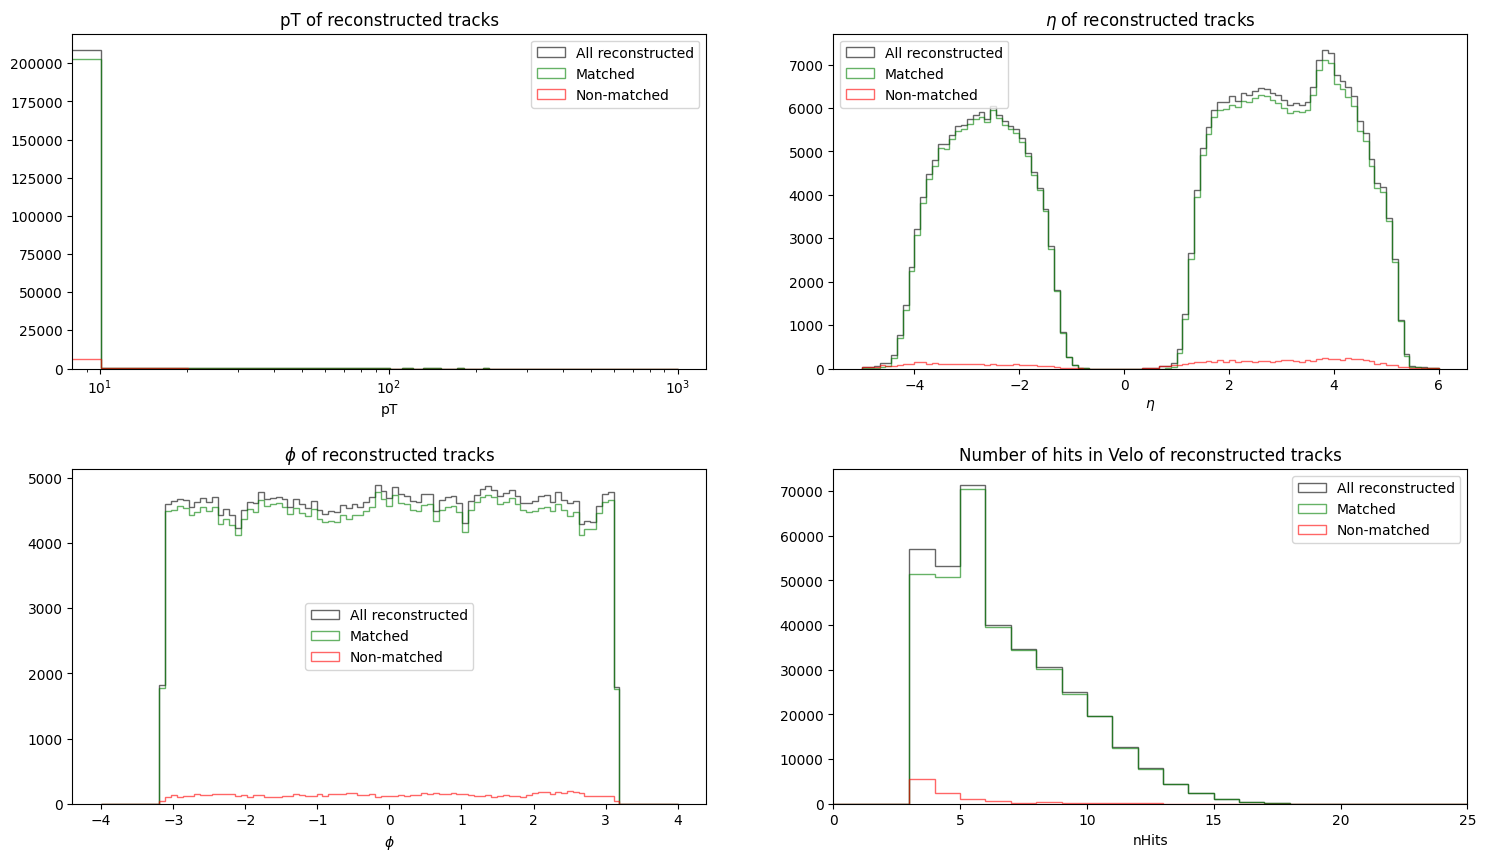

In [10]:
pt_bins = np.linspace(0, 1000, 100)
eta_bins = np.linspace(-5, 6, 100)
docaz_bins = np.linspace(-0.05, 0.15, 100)
phi_bins = np.linspace(-4, 4, 100)
nHits_bins = np.linspace(0, 40, 41)

fig, axs = plt.subplots(2, 2, figsize=(18, 10))
axs[0,0].hist(reco_tracks_df["pt"], bins=pt_bins, alpha=0.6, label="All reconstructed",
              color="black", histtype="step")
axs[0,0].hist(reco_tracks_df["pt"][reco_indices], bins=pt_bins, alpha=0.6,
              label="Matched", color="green", histtype="step")
axs[0,0].hist(reco_tracks_df["pt"][nonreco_indices], bins=pt_bins, alpha=0.6,
              label="Non-matched", color="red", histtype="step")
axs[0,0].set_title("pT of reconstructed tracks")
axs[0,0].set_xlabel("pT")
axs[0,0].set_xscale("log")
axs[0,0].legend()

# Now do eta
axs[0,1].hist(reco_tracks_df["eta"], bins=eta_bins, alpha=0.6, label="All reconstructed",
              color="black", histtype="step")
axs[0,1].hist(reco_tracks_df["eta"][reco_indices], bins=eta_bins, alpha=0.6,
              label="Matched", color="green", histtype="step")
axs[0,1].hist(reco_tracks_df["eta"][nonreco_indices], bins=eta_bins, alpha=0.6,
              label="Non-matched", color="red", histtype="step")
axs[0,1].set_title(r"$\eta$ of reconstructed tracks")
axs[0,1].set_xlabel(r"$\eta$")
axs[0,1].legend()

plt.subplots_adjust(hspace=0.3) # space for titles

# phi
axs[1,0].hist(reco_tracks_df["phi"], bins=phi_bins, alpha=0.6, label="All reconstructed",
              color="black", histtype="step")
axs[1,0].hist(reco_tracks_df["phi"][reco_indices], bins=phi_bins, alpha=0.6,
              label="Matched", color="green", histtype="step")
axs[1,0].hist(reco_tracks_df["phi"][nonreco_indices], bins=phi_bins, alpha=0.6,
              label="Non-matched", color="red", histtype="step")
axs[1,0].set_title(r"$\phi$ of reconstructed tracks")
axs[1,0].set_xlabel(r"$\phi$")
axs[1,0].legend()

# nHits
axs[1,1].hist(reco_tracks_df["nHits"], bins=nHits_bins, alpha=0.6, label="All reconstructed",
              color="black", histtype="step")
axs[1,1].hist(reco_tracks_df["nHits"][reco_indices], bins=nHits_bins, alpha=0.6,
              label="Matched", color="green", histtype="step")
axs[1,1].hist(reco_tracks_df["nHits"][nonreco_indices], bins=nHits_bins, alpha=0.6,
              label="Non-matched", color="red", histtype="step")
axs[1,1].set_title("Number of hits in Velo of reconstructed tracks")
axs[1,1].set_xlabel("nHits")
axs[1,1].set_xlim(0, 25)
axs[1,1].legend()

plt.show()

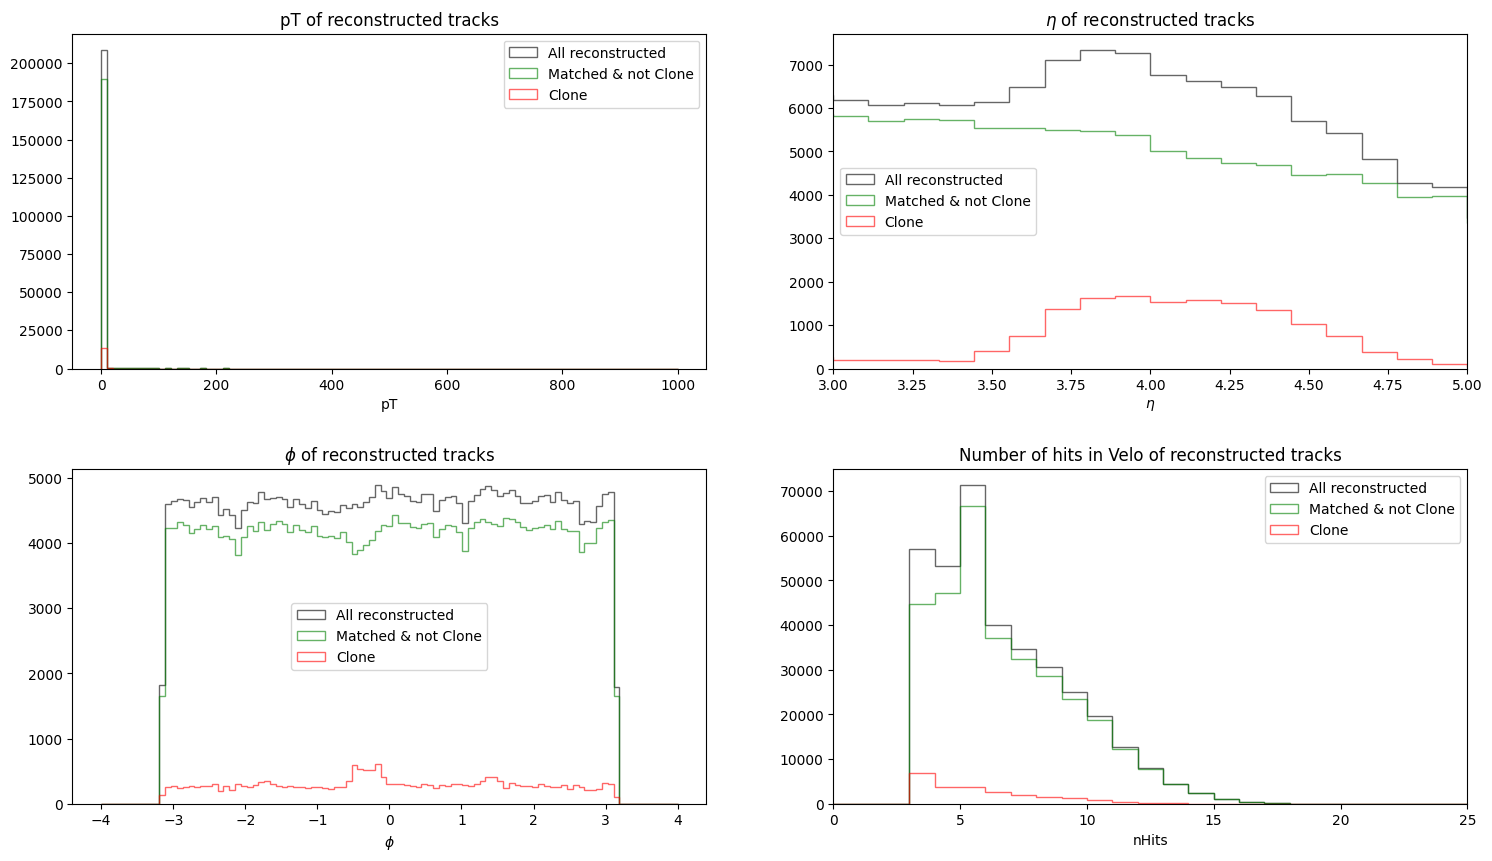

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10))
axs[0,0].hist(reco_tracks_df["pt"], bins=pt_bins, alpha=0.6, label="All reconstructed",
              color="black", histtype="step")
axs[0,0].hist(reco_tracks_df["pt"][non_clone_indices], bins=pt_bins, alpha=0.6,
              label="Matched & not Clone", color="green", histtype="step")
axs[0,0].hist(reco_tracks_df["pt"][clone_indices], bins=pt_bins, alpha=0.6,
              label="Clone", color="red", histtype="step")
axs[0,0].set_title("pT of reconstructed tracks")
axs[0,0].set_xlabel("pT")
# axs[0,0].set_xscale("log")
axs[0,0].legend()

# Now do eta
axs[0,1].hist(reco_tracks_df["eta"], bins=eta_bins, alpha=0.6, label="All reconstructed",
              color="black", histtype="step")
axs[0,1].hist(reco_tracks_df["eta"][non_clone_indices], bins=eta_bins, alpha=0.6,
              label="Matched & not Clone", color="green", histtype="step")
axs[0,1].hist(reco_tracks_df["eta"][clone_indices], bins=eta_bins, alpha=0.6,
              label="Clone", color="red", histtype="step")
axs[0,1].set_title(r"$\eta$ of reconstructed tracks")
axs[0,1].set_xlabel(r"$\eta$")
axs[0,1].set_xlim(3,5)
axs[0,1].legend()

plt.subplots_adjust(hspace=0.3) # space for titles

# phi
axs[1,0].hist(reco_tracks_df["phi"], bins=phi_bins, alpha=0.6, label="All reconstructed",
              color="black", histtype="step")
axs[1,0].hist(reco_tracks_df["phi"][non_clone_indices], bins=phi_bins, alpha=0.6,
              label="Matched & not Clone", color="green", histtype="step")
axs[1,0].hist(reco_tracks_df["phi"][clone_indices], bins=phi_bins, alpha=0.6,
              label="Clone", color="red", histtype="step")
axs[1,0].set_title(r"$\phi$ of reconstructed tracks")
axs[1,0].set_xlabel(r"$\phi$")
axs[1,0].legend()

# nHits
axs[1,1].hist(reco_tracks_df["nHits"], bins=nHits_bins, alpha=0.6, label="All reconstructed",
              color="black", histtype="step")
axs[1,1].hist(reco_tracks_df["nHits"][non_clone_indices], bins=nHits_bins, alpha=0.6,
              label="Matched & not Clone", color="green", histtype="step")
axs[1,1].hist(reco_tracks_df["nHits"][clone_indices], bins=nHits_bins, alpha=0.6,
              label="Clone", color="red", histtype="step")
axs[1,1].set_title("Number of hits in Velo of reconstructed tracks")
axs[1,1].set_xlabel("nHits")
axs[1,1].set_xlim(0, 25)
axs[1,1].legend()

plt.show()

In [13]:
# Now I want to check the typical sizes of the reconstructed tracks wrt their matched MC
recoTrackHitRate_eta_binned = np.zeros_like(wider_eta_bins[:-1], dtype=np.float32)
recoTrackHitRate_errs_eta_binned = np.zeros_like(wider_eta_bins[:-1], dtype=np.float32)
for i in range(wider_eta_bins.size - 1):
    if (i % 5 == 0 and i):
        print(f"Completed {(100*i/(wider_eta_bins.size - 1)):.3f}%.")
    rel_bin_indices = np.where((reco_tracks_df["eta"][non_clone_indices] >= wider_eta_bins[i]) *
                               (reco_tracks_df["eta"][non_clone_indices] < wider_eta_bins[i+1]))[0]
    hitFractions = np.zeros_like(rel_bin_indices, dtype=np.uint32)
    for j, match_idx in enumerate(np.array(reco_tracks_df["mcMatchIdx"][non_clone_indices])[rel_bin_indices]):
        runNo = np.array(reco_tracks_df["runNo"][non_clone_indices])[rel_bin_indices][j]
        evNo = np.array(reco_tracks_df["evNo"][non_clone_indices])[rel_bin_indices][j]
        # runNo and evNo are offset by 1
        evIdx = (runNo - 1) * kEventsPerRun + (evNo - 1)
        id_idx = mc_events_df["globalTrackOffset"][evIdx] + match_idx
        if (evIdx < (kTotalEvents - 1)):
            # print(runNo, evNo, j, evIdx, match_idx, id_idx, mc_events_df["globalTrackOffset"][evIdx])
            assert(id_idx < mc_events_df["globalTrackOffset"][evIdx + 1])
        hitFractions[j] = (np.array(reco_tracks_df["nHits"][non_clone_indices])[rel_bin_indices][j] /
                           mc_tracks_df["nHits"][id_idx])

    # get the fraction of the reconstructed tracks wrt their MC match
    recoTrackHitRate_eta_binned[i] = np.mean(hitFractions)
    recoTrackHitRate_errs_eta_binned[i] = np.std(hitFractions)

Completed 10.204%.
Completed 20.408%.
Completed 30.612%.
Completed 40.816%.


/Users/User/mambaforge/envs/jptenv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/User/mambaforge/envs/jptenv/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/User/mambaforge/envs/jptenv/lib/python3.12/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/User/mambaforge/envs/jptenv/lib/python3.12/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/User/mambaforge/envs/jptenv/lib/python3.12/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/User/mambaforge/envs/jptenv/

Completed 51.020%.
Completed 61.224%.
Completed 71.429%.
Completed 81.633%.
Completed 91.837%.


In [16]:
counts_eta_binned_clones, _ = np.histogram(reco_tracks_df["eta"][clone_indices], wider_eta_bins)
errs_eta_binned_clones = np.sqrt(counts_eta_binned_clones)
counts_eta_binned_noClones, _ = np.histogram(reco_tracks_df["eta"][non_clone_indices], wider_eta_bins)
errs_eta_binned_noClones = np.sqrt(counts_eta_binned_noClones)

ratio_eta_binned = counts_eta_binned_clones / (counts_eta_binned_clones + counts_eta_binned_noClones)

# propagate errors
errs_eta_binned_ratio = ratio_eta_binned * np.sqrt(((errs_eta_binned_noClones + errs_eta_binned_clones) /
                                                    (counts_eta_binned_noClones + counts_eta_binned_clones))**2 +
                                                   (errs_eta_binned_clones/counts_eta_binned_clones)**2)

/var/folders/_m/t8qyg5kj4ygfy22gkn6syjsm0000gn/T/ipykernel_95109/3577409858.py:6: RuntimeWarning: invalid value encountered in divide
  ratio_eta_binned = counts_eta_binned_clones / (counts_eta_binned_clones + counts_eta_binned_noClones)
/var/folders/_m/t8qyg5kj4ygfy22gkn6syjsm0000gn/T/ipykernel_95109/3577409858.py:9: RuntimeWarning: invalid value encountered in divide
  errs_eta_binned_ratio = ratio_eta_binned * np.sqrt(((errs_eta_binned_noClones + errs_eta_binned_clones) /
/var/folders/_m/t8qyg5kj4ygfy22gkn6syjsm0000gn/T/ipykernel_95109/3577409858.py:11: RuntimeWarning: invalid value encountered in divide
  (errs_eta_binned_clones/counts_eta_binned_clones)**2)


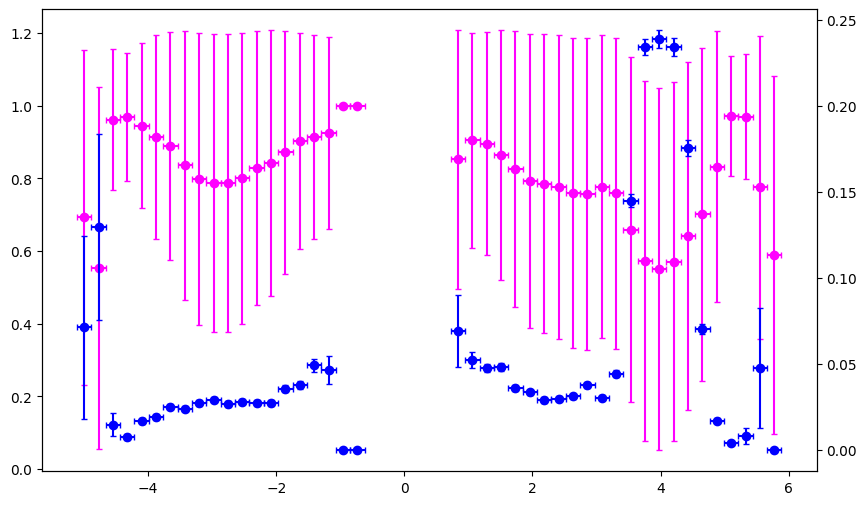

In [18]:
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(wider_eta_bins[:-1], recoTrackHitRate_eta_binned, xerr=wider_eta_bin_width/2,
            yerr=recoTrackHitRate_errs_eta_binned, color="magenta", label="Track hit ratio",
            marker='o', ls="none", capsize=2)
ax2 = ax.twinx()  # get one for plotting clone rate by eta
ax2.errorbar(wider_eta_bins[:-1], ratio_eta_binned, xerr=wider_eta_bin_width/2,
             yerr=errs_eta_binned_ratio, color="blue", label="Clone ratio",
             marker='o', ls="none", capsize=2)
plt.show()

In [ ]:
plt.hist(reco_tracks_df["mcMatchWeight"][clone_indices], histtype="step")
plt.hist(reco_tracks_df["mcMatchWeight"][non_clone_indices], histtype="step")
plt.yscale("log")
plt.show()

In [14]:
evNoBinSize = 5
runNoBins = np.arange(1, 12)
evNoBins = np.arange(1, 202, evNoBinSize)
counts_runNo_clones, _ = np.histogram(reco_tracks_df["runNo"][clone_indices], runNoBins)
errs_runNo_clones = np.sqrt(counts_runNo_clones)
counts_runNo_noClones, _ = np.histogram(reco_tracks_df["runNo"][non_clone_indices], runNoBins)
errs_runNo_noClones = np.sqrt(counts_runNo_noClones)

counts_evNo_clones, _ = np.histogram(reco_tracks_df["evNo"][clone_indices], evNoBins)
errs_evNo_clones = np.sqrt(counts_evNo_clones)
counts_evNo_noClones, _ = np.histogram(reco_tracks_df["evNo"][non_clone_indices], evNoBins)
errs_evNo_noClones = np.sqrt(counts_evNo_noClones)

ratio_runNo = counts_runNo_clones / counts_runNo_noClones
ratio_evNo = counts_evNo_clones / counts_evNo_noClones

errs_evNo_ratio = ratio_evNo * np.sqrt((errs_evNo_noClones/counts_evNo_noClones)**2 +
                                       (errs_evNo_clones/counts_evNo_clones)**2)
errs_runNo_ratio = ratio_runNo * np.sqrt((errs_runNo_noClones/counts_runNo_noClones)**2 +
                                       (errs_runNo_clones/counts_runNo_clones)**2)

/var/folders/_m/t8qyg5kj4ygfy22gkn6syjsm0000gn/T/ipykernel_95109/198947761.py:14: RuntimeWarning: invalid value encountered in divide
  ratio_runNo = counts_runNo_clones / counts_runNo_noClones
/var/folders/_m/t8qyg5kj4ygfy22gkn6syjsm0000gn/T/ipykernel_95109/198947761.py:19: RuntimeWarning: invalid value encountered in divide
  errs_runNo_ratio = ratio_runNo * np.sqrt((errs_runNo_noClones/counts_runNo_noClones)**2 +
/var/folders/_m/t8qyg5kj4ygfy22gkn6syjsm0000gn/T/ipykernel_95109/198947761.py:20: RuntimeWarning: invalid value encountered in divide
  (errs_runNo_clones/counts_runNo_clones)**2)


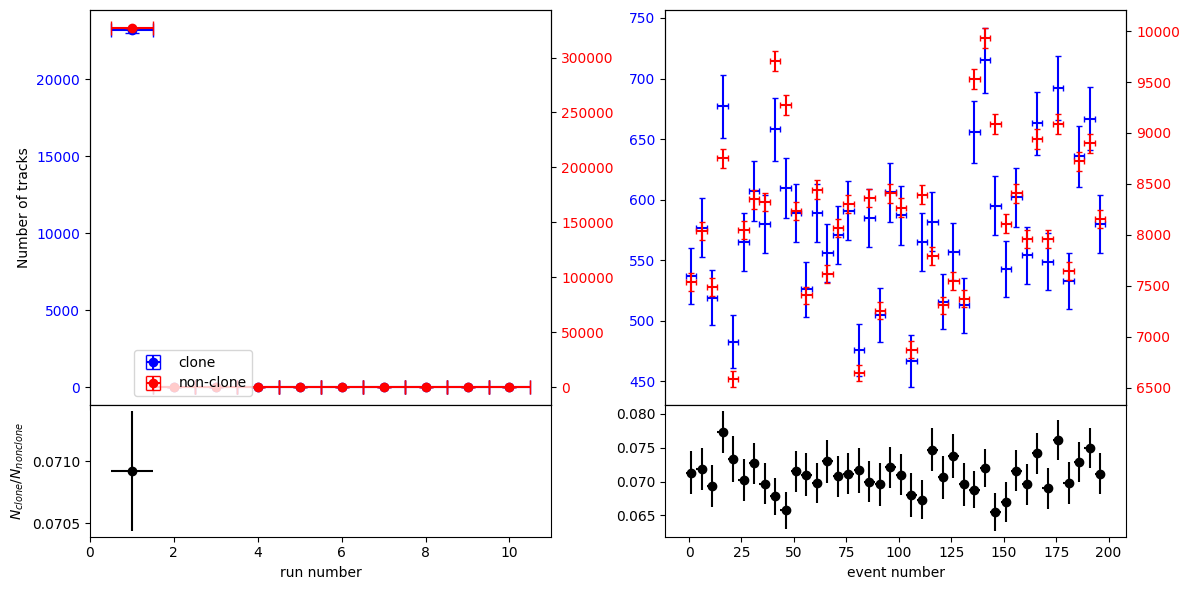

360523


In [15]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 6),
                        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.0},
                        sharex='col')
axs[0,0].errorbar(runNoBins[:-1], counts_runNo_clones, xerr=0.5,  # xerr is just bin width / 2
                  yerr=errs_runNo_clones, color="blue", label="clone",
                  marker='o', ls="none", capsize=5)
axs[0,0].set_ylabel("Number of tracks")
axs[0,0].tick_params(axis="y", labelcolor="blue")
ax1 = axs[0,0].twinx()
ax1.errorbar(runNoBins[:-1], counts_runNo_noClones, xerr=0.5,
             yerr=errs_runNo_clones, color="red", label="non-clone",
             marker='o', ls="none", capsize=5)
ax1.tick_params(axis="y", labelcolor="red")
fig.legend(bbox_to_anchor=(0.22,0.42))

# and the related ratio + errors
axs[1,0].errorbar(runNoBins[:-1], ratio_runNo, xerr=0.5,
                  yerr=errs_runNo_ratio, marker='o', ls='none',
                  color='black')
axs[1,0].set_xlabel('run number')
axs[1,0].set_ylabel(r'$N_{clone} / N_{nonclone}$')


# Now plot per event basis
axs[0,1].errorbar(evNoBins[:-1], counts_evNo_clones, xerr=evNoBinSize/2,
                  yerr=errs_evNo_clones, color="blue", ls="none", capsize=2)
axs[0,1].set_xlabel("event number")
axs[0,1].tick_params(axis="y", labelcolor="blue")
ax2 = axs[0,1].twinx()
ax2.errorbar(evNoBins[:-1], counts_evNo_noClones, xerr=evNoBinSize/2,
                  yerr=errs_evNo_noClones, color="red", ls="none", capsize=2)
ax2.tick_params(axis="y", labelcolor="red")

# and the related ratio + errors for per event basis
axs[1,1].errorbar(evNoBins[:-1], ratio_evNo, xerr=evNoBinSize/2,
                  yerr=errs_evNo_ratio, marker='o', ls='none',
                  color='black')
axs[1,1].set_xlabel('event number')

fig.tight_layout() # space for axis ticks
plt.show()

print(reco_tracks_df["runNo"].size)

In [ ]:
hit_0_5_track_indices_reco = np.where(reco_tracks_df["nHits"] <= 5)[0]
hit_0_10_track_indices_reco = np.where(reco_tracks_df["nHits"] <= 10)[0]
hit_0_15_track_indices_reco = np.where(reco_tracks_df["nHits"] <= 15)[0]

hit_0_5_track_indices_mc_reco = np.where((mc_tracks_df["nHits"] <= 5) * isReconstructible)[0]
hit_0_10_track_indices_mc_reco = np.where((mc_tracks_df["nHits"] <= 10) * isReconstructible)[0]
hit_0_15_track_indices_mc_reco = np.where((mc_tracks_df["nHits"] <= 15) * isReconstructible)[0]

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(reco_tracks_df["eta"][hit_0_5_track_indices_reco], bins=eta_bins,
            label=r"$n_{hits} \leq 5$", color="magenta", histtype="step")
axs[0].hist(reco_tracks_df["eta"][hit_0_10_track_indices_reco], bins=eta_bins,
            label=r"$n_{hits} \leq 10$", color="green", histtype="step")
axs[0].hist(reco_tracks_df["eta"][hit_0_15_track_indices_reco], bins=eta_bins,
            label=r"$n_{hits} \leq 15$", color="blue", histtype="step")
axs[0].hist(reco_tracks_df["eta"], bins=eta_bins,
            label="All", color="k", histtype="step")
axs[0].set_title(r"$\eta$ distributions of reconstructed tracks")
axs[0].set_xlabel(r"$\eta$")
# axs[0,0].set_xscale("log")
fig.legend(bbox_to_anchor=(0.3,0.9))

axs[1].hist(mc_tracks_df["eta"][hit_0_5_track_indices_mc_reco], bins=eta_bins,
            label=r"$n_{hits} \leq 5$", color="magenta", histtype="step")
axs[1].hist(mc_tracks_df["eta"][hit_0_10_track_indices_mc_reco], bins=eta_bins,
            label=r"$n_{hits} \leq 10$", color="green", histtype="step")
axs[1].hist(mc_tracks_df["eta"][hit_0_15_track_indices_mc_reco], bins=eta_bins,
            label=r"$n_{hits} \leq 15$", color="blue", histtype="step")
axs[1].hist(mc_tracks_df["eta"][reconstructible_indices], bins=eta_bins,
            label="All", color="k", histtype="step")
axs[1].set_title(r"$\eta$ distributions of MC tracks")
axs[1].set_xlabel(r"$\eta$")

fig.tight_layout()
plt.show()

### Clone plots of MC particles

In [ ]:
print(np.argmax(mc_tracks_df["nMatches"]))
low_hit_track_indices = np.where((mc_tracks_df["nHits"] < 6) * isReconstructible)[0]

In [ ]:
print(mc_tracks_df["matchedTracks"][reconstructible_indices])

In [ ]:
kDupl_eta_binned = np.zeros_like(wider_eta_bins[:-1], dtype=np.float32)
kDupl_errs_eta_binned = np.zeros_like(wider_eta_bins[:-1], dtype=np.float32)
nHits_MC_eta_binned = np.zeros_like(wider_eta_bins[:-1], dtype=np.float32)
nHits_MC_errs_eta_binned = np.zeros_like(wider_eta_bins[:-1], dtype=np.float32)
assocHitRate_eta_binned = np.zeros_like(wider_eta_bins[:-1], dtype=np.float32)
assocHitRate_errs_eta_binned = np.zeros_like(wider_eta_bins[:-1], dtype=np.float32)

In [ ]:
print(reco_tracks_df["nHits"].size, np.array(reco_events_df["globalTrackOffset"])[-1])

In [ ]:
for i in range(wider_eta_bins.size - 1):
    # print(f"Completed {(100*i/(wider_eta_bins.size - 1)):.3f}%.")
    rel_bin_indices = np.where((mc_tracks_df["eta"][reconstructible_reco_indices] >= wider_eta_bins[i]) *
                               (mc_tracks_df["eta"][reconstructible_reco_indices] < wider_eta_bins[i+1]))[0]
    if (rel_bin_indices.size == 0):  # ignore if nothing in bin
        continue
    # remember to remove the minus 1 since it's the number of duplicates we are looking for
    # can be outside for mean since now we just take -1 to a number, but has to be inside for std
    kDupl_eta_binned[i] = np.mean(np.array(mc_tracks_df["nMatches"][reconstructible_reco_indices])
                                          [rel_bin_indices]) - 1
    kDupl_errs_eta_binned[i] = np.std(np.array(mc_tracks_df["nMatches"][reconstructible_reco_indices])
                                              [rel_bin_indices] - 1)# / np.sqrt(rel_bin_indices.size)
    nHits_MC_eta_binned[i] = np.mean(np.array(mc_tracks_df["nHits"][reconstructible_reco_indices])
                                          [rel_bin_indices]) - 1
    nHits_MC_errs_eta_binned[i] = np.std(np.array(mc_tracks_df["nHits"][reconstructible_reco_indices])
                                              [rel_bin_indices] - 1)# / np.sqrt(rel_bin_indices.size)
    # now get full match rates
    nHitsRecodTotal = np.zeros_like(rel_bin_indices, dtype=np.uint32)
    for j, matches in enumerate(np.array(mc_tracks_df["matchedTracks"][reconstructible_reco_indices])[rel_bin_indices]):
        for match_idx in matches:
            runNo = np.array(mc_tracks_df["runNo"][reconstructible_reco_indices])[rel_bin_indices][j]
            evNo = np.array(mc_tracks_df["evNo"][reconstructible_reco_indices])[rel_bin_indices][j]
            # runNo and evNo are offset by 1
            evIdx = (runNo - 1) * kEventsPerRun + (evNo - 1)
            id_idx = reco_events_df["globalTrackOffset"][evIdx] + match_idx
            if (evIdx < (kTotalEvents - 1)):
                # print(runNo, evNo, j, evIdx, matches, match_idx, id_idx, reco_events_df["globalTrackOffset"][evIdx])
                assert(id_idx < reco_events_df["globalTrackOffset"][evIdx + 1])
            nHitsRecodTotal[j] += reco_tracks_df["nHits"][id_idx]

    # get the fraction reconstructed
    assocHitRate_eta_binned[i] = (
        np.mean(nHitsRecodTotal /
                np.array(mc_tracks_df["nHits"][reconstructible_reco_indices])[rel_bin_indices]))
    assocHitRate_errs_eta_binned[i] = (
        np.std(nHitsRecodTotal /
               np.array(mc_tracks_df["nHits"][reconstructible_reco_indices])[rel_bin_indices]))

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(12,8))
axs[0,0].errorbar(wider_eta_bin_centres, kDupl_eta_binned, xerr=wider_eta_bin_width/2,
                  yerr=kDupl_errs_eta_binned, linestyle='', color="k", capsize=3)
axs[0,0].set_title("Number of clone tracks matched to MC Particles, averaged in eta bins")
axs[0,0].set_xlabel(r"$\eta$")
axs[0,0].set_ylabel(r"$N_{clones}$")
# axs[0].legend()

axs[0,1].errorbar(wider_eta_bin_centres, nHits_MC_eta_binned, xerr=wider_eta_bin_width/2,
                  yerr=nHits_MC_errs_eta_binned, linestyle='', color="k", capsize=3)
axs[0,1].set_title(r"Number of hits of MC Particles by $\eta$")
axs[0,1].set_xlabel(r"$\eta$")
axs[0,1].set_ylabel(r"$N_{hits}$")

axs[1,0].errorbar(wider_eta_bin_centres, assocHitRate_eta_binned, xerr=wider_eta_bin_width/2,
                  yerr=assocHitRate_errs_eta_binned, linestyle='', color="k", capsize=3)
axs[1,0].set_title(r"Fraction of MC Hits reconstructed over all clones wrt $\eta$")
axs[1,0].set_xlabel(r"$\eta$")
axs[1,0].set_ylabel(r"$\sum N_{hits}^{reco} / N_{hits}^{sim}$")
axs[1,0].set_ylim(0.9, 1.1)

axs[1,1].hist(mc_tracks_df["eta"][reconstructible_indices], bins=eta_bins,
              color="b", label="All", histtype="step")
axs[1,1].hist(mc_tracks_df["eta"][low_hit_track_indices], bins=eta_bins,
              color="magenta", label=r"$n_{hits} \leq 5$", histtype="step")
# axs[1,1].set_yscale("log")
axs[1,1].set_title(r"$\eta$ distribution of reconstructible tracks")
axs[1,1].set_xlabel(r"$\eta$")
axs[1,1].set_ylabel("Frequency")
axs[1,1].legend()

fig.tight_layout()
plt.show()

In [ ]:
no_clone_indices_mc = np.where((mc_tracks_df["nMatches"] == 1) * isReconstructible)[0]
clone_indices_mc = np.where((mc_tracks_df["nMatches"] > 1) * isReconstructible)[0]
high_clone_indices_mc = np.where((mc_tracks_df["nMatches"] > 5) * isReconstructible)[0]

In [ ]:
# nHits
plt.hist(mc_tracks_df["nHits"][reconstructible_nonreco_indices], bins=nHits_bins,
            color="k", histtype="step", label="Non-reconstructed")
plt.hist(mc_tracks_df["nHits"][no_clone_indices_mc], bins=nHits_bins,
            color="g", histtype="step", label="No clones & reco")
plt.hist(mc_tracks_df["nHits"][clone_indices_mc], bins=nHits_bins,
            color="r", histtype="step", label="Has clones")
plt.hist(mc_tracks_df["nHits"][high_clone_indices_mc], bins=nHits_bins,
            color="b", histtype="step", label=r"Has $\geq 5$ clones")
plt.title("Number of hits of MC Particles")
plt.xlabel(r"$N_{hits}$")
plt.ylabel("Frequency")
plt.yscale("log")
plt.legend()

plt.show()

In [ ]:
# Only use to get the number of unique IDs on an event basis

kIDsPerEvent = np.zeros_like(mc_events_df["evNo"], dtype=np.uint32)
kUniqueIDsPerEvent = np.zeros_like(mc_events_df["evNo"], dtype=np.uint32)
for runNo in range(kRuns):
    print(f"Run {runNo}.")
    for evNo in range(kEventsPerRun):
        if (evNo % 10 == 0 and evNo):
            print(f"Event {evNo}.")
        relevant_indices_id = np.where((mc_tracks_df["runNo"] == (runNo + 1)) *
                                       (mc_tracks_df["evNo"] == (evNo+1)))[0]
        kIDs = mc_tracks_df["lhcbid"][relevant_indices_id].size
        kUniqueIDs = mc_tracks_df["lhcbid"][relevant_indices_id].unique().size
        kIDsPerEvent[runNo * kEventsPerRun + evNo] = kIDs
        kUniqueIDsPerEvent[runNo * kEventsPerRun + evNo] = kUniqueIDs

In [ ]:
event_bins = np.linspace(1, kTotalEvents+1, 21, dtype=np.uint32)
event_bin_width = event_bins[1] - event_bins[0]
event_bin_centres = event_bins[:-1] + event_bin_width / 2
print(event_bin_centres, event_bin_width)

In [ ]:
kIDsPerEventBinned = np.zeros_like(event_bins[:-1], dtype=np.uint32)
kUniqueIDsPerEventBinned = np.zeros_like(event_bins[:-1], dtype=np.uint32)
globalEvNo = mc_events_df["evNo"] + (mc_events_df["runNo"] - 1) * kEventsPerRun
for i in range(event_bins.size - 1):
    rel_bin_indices = np.where((globalEvNo >= event_bins[i]) *
                               (globalEvNo < event_bins[i+1]))[0]
    kIDsPerEventBinned[i] = np.sum(kIDsPerEvent[rel_bin_indices])
    kUniqueIDsPerEventBinned[i] = np.sum(kUniqueIDsPerEvent[rel_bin_indices])

In [ ]:
errs_ids = np.sqrt(kIDsPerEventBinned)
errs_unique_ids = np.sqrt(kUniqueIDsPerEventBinned)
id_ratio = kIDsPerEventBinned / kUniqueIDsPerEventBinned

errs_id_ratio = id_ratio * np.sqrt((errs_ids/kIDsPerEventBinned)**2 +
                                   (errs_unique_ids/kUniqueIDsPerEventBinned)**2)

In [ ]:
plt.errorbar(event_bin_centres, id_ratio, xerr=event_bin_width / 2,
             yerr=errs_id_ratio, color="k", capsize=5, fmt="o")
plt.show()
print(f"Average: {np.mean(id_ratio)}")

In [ ]:
print(np.array(mc_tracks_df["matchedTracks"][recod_indices])[1895])
print(np.array(mc_tracks_df["evNo"][recod_indices])[1895])
mc_events_df["globalTrackOffset"]

In [19]:
id_reco_dupl_rate = np.zeros_like(mc_tracks_df["eta"][recod_indices])
for idx, matches in enumerate(mc_tracks_df["matchedTracks"][recod_indices]):
    unique_indices = set()
    n_ids_total = 0
    if ((idx % 3000 == 0) and idx):
        print(f"{((idx / recod_indices.size)*100):.3f}% done")
    for match_idx in matches:
        #print(idx)
        runNo = np.array(mc_tracks_df["runNo"][recod_indices])[idx]
        evNo = np.array(mc_tracks_df["evNo"][recod_indices])[idx]
        # runNo and evNo are offset by 1
        evIdx = (runNo - 1) * kEventsPerRun + (evNo - 1)
        id_idx = reco_events_df["globalTrackOffset"][evIdx] + match_idx
        if (evIdx != (kTotalEvents - 1)):
            # if (idx > 0):
            #     print(runNo, evNo, idx, evIdx, matches, match_idx, id_idx, reco_events_df["globalTrackOffset"][evIdx], reco_events_df["globalTrackOffset"][evIdx + 1])
            assert(id_idx < reco_events_df["globalTrackOffset"][evIdx + 1])
        n_ids_total += reco_tracks_df["nHits"][id_idx]
        for lhcbid in reco_tracks_df["lhcbid"][id_idx]:
            unique_indices.add(lhcbid)

    id_reco_dupl_rate[idx] = len(unique_indices) / n_ids_total

0.918% done
1.836% done
2.754% done
3.672% done
4.590% done
5.508% done
6.426% done
7.344% done
8.261% done
9.179% done
10.097% done
11.015% done
11.933% done
12.851% done
13.769% done
14.687% done
15.605% done
16.523% done
17.441% done
18.359% done
19.277% done
20.195% done
21.113% done
22.031% done
22.948% done
23.866% done
24.784% done
25.702% done
26.620% done
27.538% done
28.456% done
29.374% done
30.292% done
31.210% done
32.128% done
33.046% done
33.964% done
34.882% done
35.800% done
36.718% done
37.636% done
38.553% done
39.471% done
40.389% done
41.307% done
42.225% done
43.143% done
44.061% done
44.979% done
45.897% done
46.815% done
47.733% done
48.651% done
49.569% done
50.487% done
51.405% done
52.323% done
53.240% done
54.158% done
55.076% done
55.994% done
56.912% done
57.830% done
58.748% done
59.666% done
60.584% done
61.502% done
62.420% done
63.338% done
64.256% done
65.174% done
66.092% done
67.010% done
67.928% done
68.845% done
69.763% done
70.681% done
71.599% d

In [ ]:
id_reco_dupl_rate_eta_binned = np.zeros_like(eta_bin_centres)
id_reco_dupl_rate_eta_binned_err = np.zeros_like(eta_bin_centres)

In [ ]:
for i in range(eta_bins.size - 1):
    rel_bin_indices = np.where((mc_tracks_df["eta"][recod_indices] >= eta_bins[i]) *
                               (mc_tracks_df["eta"][recod_indices] < eta_bins[i+1]))[0]
    if (rel_bin_indices.size == 0):
        continue
    id_reco_dupl_rate_eta_binned[i] = np.mean(1 - id_reco_dupl_rate[rel_bin_indices])
    id_reco_dupl_rate_eta_binned_err[i] = np.std(1 - id_reco_dupl_rate[rel_bin_indices])

In [ ]:
plt.errorbar(eta_bin_centres, id_reco_dupl_rate_eta_binned, xerr=eta_bin_width / 2,
             yerr=id_reco_dupl_rate_eta_binned_err, color="k", capsize=2, fmt="o")
plt.xlim(2,5)
plt.show()

In [ ]:
plt.hist(1-id_reco_dupl_rate, bins=100),
plt.yscale("log")
plt.show()